In [1]:
!pip install kaggle shap networkx scikit-learn pandas numpy matplotlib joblib --quiet

In [2]:
!pip install kaggle shap networkx scikit-learn pandas numpy matplotlib joblib --quiet

In [3]:
from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# Download HI-Small (high illicit ratio) + LI-Small (low illicit ratio)
# Together they give the model DIVERSE behavior to learn from
!kaggle datasets download -d ealtman2019/ibm-transactions-for-anti-money-laundering-aml \
    --file HI-Small_Trans.csv -p /content/data/
!kaggle datasets download -d ealtman2019/ibm-transactions-for-anti-money-laundering-aml \
    --file LI-Small_Trans.csv -p /content/data/

!cd /content/data && unzip -q "*.zip" 2>/dev/null || true
!ls -lh /content/data/

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 454M/454M [00:04<00:00, 103MB/s]

Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 620M/620M [00:03<00:00, 171MB/s]

total 1.1G
-rw-r--r-- 1 root root 454M Jul  8  2025 HI-Small_Trans.csv
-rw-r--r-- 1 root root 621M Jul  8  2025 LI-Small_Trans.csv


In [4]:
import pandas as pd
import numpy as np

hi = pd.read_csv('/content/data/HI-Small_Trans.csv')
li = pd.read_csv('/content/data/LI-Small_Trans.csv')

df = pd.concat([hi, li], ignore_index=True)
del hi, li  # free RAM

print("Combined shape:", df.shape)
print("Columns:", df.columns.tolist())

# Parse timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)
df.dropna(inplace=True)

# Standardize amount column — use Amount Paid as the base
df.rename(columns={
    'Account': 'sender',
    'Account.1': 'receiver',
    'Amount Paid': 'amount',
    'Is Laundering': 'label',
    'Payment Currency': 'pay_currency',
    'Receiving Currency': 'recv_currency',
    'Payment Format': 'pay_format',
    'From Bank': 'from_bank',
    'To Bank': 'to_bank',
}, inplace=True)

print("\nLabel distribution:")
print(df['label'].value_counts())
print(f"Fraud rate: {df['label'].mean()*100:.3f}%")

Combined shape: (12002394, 11)
Columns: ['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1', 'Amount Received', 'Receiving Currency', 'Amount Paid', 'Payment Currency', 'Payment Format', 'Is Laundering']

Label distribution:
label
0    11993652
1        8742
Name: count, dtype: int64
Fraud rate: 0.073%


In [5]:
agg = df.groupby('sender').agg(
    txn_count        = ('amount', 'count'),
    avg_amount       = ('amount', 'mean'),
    std_amount       = ('amount', 'std'),
    max_amount       = ('amount', 'max'),
    min_amount       = ('amount', 'min'),
    total_sent       = ('amount', 'sum'),
    unique_receivers = ('receiver', 'nunique'),
    unique_banks_to  = ('to_bank', 'nunique'),
    unique_banks_from= ('from_bank', 'nunique'),
    label            = ('label', 'max'),
).reset_index()

agg['std_amount']      = agg['std_amount'].fillna(0)
agg['fan_out_ratio']   = agg['unique_receivers'] / (agg['txn_count'] + 1)
agg['cross_bank_ratio']= agg['unique_banks_to'] / (agg['unique_banks_from'] + 1)
agg['amount_cv']       = agg['std_amount'] / (agg['avg_amount'] + 1)
agg['amount_range']    = agg['max_amount'] - agg['min_amount']

print("Behavioral features done:", agg.shape)

Behavioral features done: (1166980, 15)


In [6]:
df['hour']      = df['Timestamp'].dt.hour
df['dayofweek'] = df['Timestamp'].dt.dayofweek
df['is_night']  = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['is_weekend']= (df['dayofweek'] >= 5).astype(int)

temp = df.groupby('sender').agg(
    avg_hour         = ('hour', 'mean'),
    std_hour         = ('hour', 'std'),       # high = random timing
    night_ratio      = ('is_night', 'mean'),
    weekend_ratio    = ('is_weekend', 'mean'),
    first_txn        = ('Timestamp', 'min'),
    last_txn         = ('Timestamp', 'max'),
).reset_index()

# Account lifespan in days
temp['account_life_days'] = (temp['last_txn'] - temp['first_txn']).dt.total_seconds() / 86400
temp['std_hour'] = temp['std_hour'].fillna(0)

# Velocity: transactions per active day
temp = temp.merge(agg[['sender','txn_count']], on='sender')
temp['txn_velocity'] = temp['txn_count'] / (temp['account_life_days'] + 1)

temp_feat = temp[['sender','avg_hour','std_hour','night_ratio','weekend_ratio',
                   'account_life_days','txn_velocity']].copy()

print("Temporal features done:", temp_feat.shape)

Temporal features done: (1166980, 7)


In [7]:
# Structuring: amounts just below $10,000 (classic smurfing pattern)
df['just_below_10k'] = ((df['amount'] >= 9000) & (df['amount'] < 10000)).astype(int)

# Round number suspicion: exact multiples of 1000
df['is_round_1000'] = ((df['amount'] % 1000 == 0) & (df['amount'] > 0)).astype(int)
df['is_round_500']  = ((df['amount'] % 500  == 0) & (df['amount'] > 0)).astype(int)

# Currency mismatch: payment currency != receiving currency (layering signal)
df['currency_change'] = (df['pay_currency'] != df['recv_currency']).astype(int)

aml = df.groupby('sender').agg(
    structuring_ratio    = ('just_below_10k', 'mean'),
    round_1000_ratio     = ('is_round_1000', 'mean'),
    round_500_ratio      = ('is_round_500', 'mean'),
    currency_change_ratio= ('currency_change', 'mean'),
    unique_formats       = ('pay_format', 'nunique'),  # many formats = layering
).reset_index()

print("AML-specific features done:", aml.shape)

AML-specific features done: (1166980, 6)


In [8]:
import networkx as nx

print("Building transaction graph...")
G = nx.DiGraph()

# Build graph from all transactions
edges = list(zip(df['sender'], df['receiver'], df['amount']))
for sender, receiver, amount in edges:
    if G.has_edge(sender, receiver):
        G[sender][receiver]['weight'] += amount
        G[sender][receiver]['count'] += 1
    else:
        G.add_edge(sender, receiver, weight=amount, count=1)

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Compute graph features for each sender node
print("Computing PageRank...")
pagerank = nx.pagerank(G, alpha=0.85, max_iter=100)

print("Computing degree centrality...")
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Weakly connected component size (large component = more embedded in network)
print("Computing component sizes...")
wcc_sizes = {}
for component in nx.weakly_connected_components(G):
    size = len(component)
    for node in component:
        wcc_sizes[node] = size

# Build graph feature dataframe
senders = agg['sender'].tolist()

graph_feats = pd.DataFrame({
    'sender'        : senders,
    'pagerank'      : [pagerank.get(s, 0) for s in senders],
    'in_degree'     : [in_deg.get(s, 0)   for s in senders],
    'out_degree'    : [out_deg.get(s, 0)  for s in senders],
    'wcc_size'      : [wcc_sizes.get(s, 1) for s in senders],
})

# Degree ratio: high out/in = funds flowing out disproportionately
graph_feats['degree_ratio'] = graph_feats['out_degree'] / (graph_feats['in_degree'] + 1)

print("Graph features done:", graph_feats.shape)

Building transaction graph...
Graph: 1208958 nodes, 2394510 edges
Computing PageRank...
Computing degree centrality...
Computing component sizes...
Graph features done: (1166980, 6)


In [9]:
feat = agg.merge(temp_feat, on='sender', how='left')
feat = feat.merge(aml,       on='sender', how='left')
feat = feat.merge(graph_feats, on='sender', how='left')

feat.fillna(0, inplace=True)

print("Final feature matrix:", feat.shape)
print("Label distribution:\n", feat['label'].value_counts())
feat.to_csv('/content/feature_matrix.csv', index=False)
print("Saved feature_matrix.csv")

Final feature matrix: (1166980, 31)
Label distribution:
 label
0    1161222
1       5758
Name: count, dtype: int64
Saved feature_matrix.csv


In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler   # better than StandardScaler for financial data
from sklearn.model_selection import train_test_split
import joblib

FEATURE_COLS = [
    'txn_count','avg_amount','std_amount','max_amount','min_amount',
    'total_sent','unique_receivers','unique_banks_to','unique_banks_from',
    'fan_out_ratio','cross_bank_ratio','amount_cv','amount_range',
    'avg_hour','std_hour','night_ratio','weekend_ratio',
    'account_life_days','txn_velocity',
    'structuring_ratio','round_1000_ratio','round_500_ratio',
    'currency_change_ratio','unique_formats',
    'pagerank','in_degree','out_degree','wcc_size','degree_ratio',
]

X = feat[FEATURE_COLS].values
y = feat['label'].values

# Train/test split — stratified so both splits have fraud cases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# RobustScaler uses median/IQR — doesn't get wrecked by extreme transaction amounts
scaler = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Actual fraud rate → use as contamination
fraud_rate = y_train.mean()
print(f"Fraud rate in training set: {fraud_rate*100:.3f}%")

iso = IsolationForest(
    n_estimators  = 300,          # 300 trees = much more stable than 100
    max_samples   = 'auto',       # 256 samples per tree (default)
    contamination = float(fraud_rate),
    random_state  = 42,
    n_jobs        = -1,           # all CPU cores
    verbose       = 1,
)

print("Training Isolation Forest with 300 trees...")
iso.fit(X_train_s)
print("Done.")

Fraud rate in training set: 0.493%
Training Isolation Forest with 300 trees...


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    2.8s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   10.0s


Done.


[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:   15.9s finished


In [11]:
from sklearn.metrics import f1_score, precision_recall_curve, roc_auc_score, average_precision_score
import numpy as np

# Raw anomaly scores on test set (lower = more anomalous)
raw_scores = iso.score_samples(X_test_s)
# Flip sign so higher = more suspicious
suspicion_scores = -raw_scores

# Sweep thresholds → find the one that maximises F1 for the laundering class
thresholds = np.percentile(suspicion_scores, np.linspace(80, 99.5, 200))

best_f1, best_thresh = 0, None
for t in thresholds:
    preds = (suspicion_scores >= t).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best threshold: {best_thresh:.4f}")
print(f"Best F1 for laundering class: {best_f1:.4f}")

# Final predictions with tuned threshold
final_preds = (suspicion_scores >= best_thresh).astype(int)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    4.3s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    8.1s finished


Best threshold: 0.5940
Best F1 for laundering class: 0.0412


=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    232244
  Laundering       0.03      0.08      0.04      1152

    accuracy                           0.98    233396
   macro avg       0.51      0.53      0.52    233396
weighted avg       0.99      0.98      0.99    233396

ROC-AUC:  0.7914
PR-AUC:   0.0252   ← most meaningful metric for imbalanced AML data


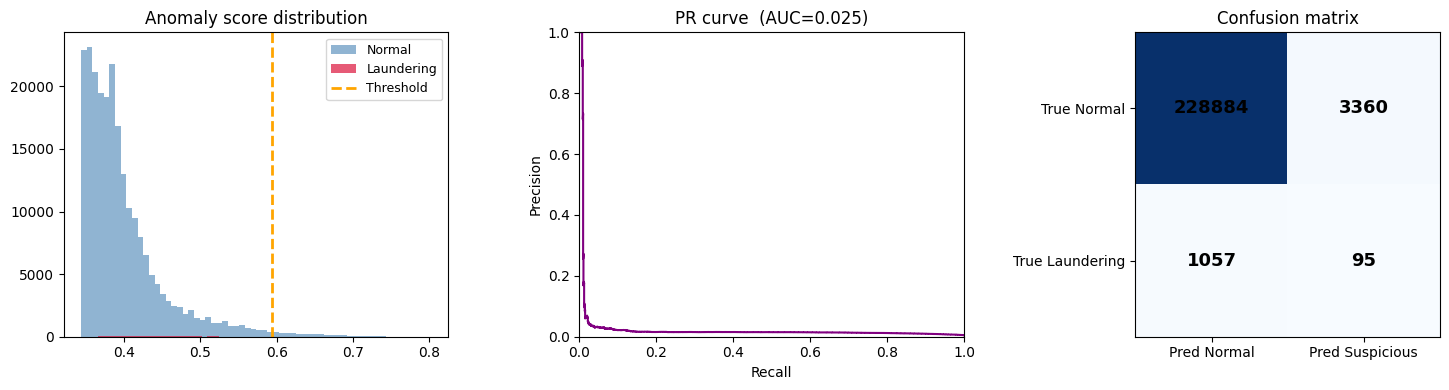

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Classification report
print("=== Classification Report ===")
print(classification_report(y_test, final_preds, target_names=['Normal','Laundering']))

roc_auc = roc_auc_score(y_test, suspicion_scores)
pr_auc  = average_precision_score(y_test, suspicion_scores)
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}   ← most meaningful metric for imbalanced AML data")

# Plots
fig = plt.figure(figsize=(15, 4))
gs  = gridspec.GridSpec(1, 3)

# 1. Score distributions
ax1 = fig.add_subplot(gs[0])
ax1.hist(suspicion_scores[y_test==0], bins=60, alpha=0.6, label='Normal', color='steelblue')
ax1.hist(suspicion_scores[y_test==1], bins=60, alpha=0.7, label='Laundering', color='crimson')
if best_thresh:
    ax1.axvline(best_thresh, color='orange', lw=2, linestyle='--', label='Threshold')
ax1.set_title('Anomaly score distribution')
ax1.legend(fontsize=9)

# 2. Precision-Recall curve
ax2 = fig.add_subplot(gs[1])
prec, rec, _ = precision_recall_curve(y_test, suspicion_scores)
ax2.plot(rec, prec, color='purple', lw=1.5)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title(f'PR curve  (AUC={pr_auc:.3f})')
ax2.set_xlim(0,1); ax2.set_ylim(0,1)

# 3. Confusion matrix
ax3 = fig.add_subplot(gs[2])
cm  = confusion_matrix(y_test, final_preds)
ax3.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=13, fontweight='bold')
ax3.set_xticks([0,1]); ax3.set_yticks([0,1])
ax3.set_xticklabels(['Pred Normal','Pred Suspicious'])
ax3.set_yticklabels(['True Normal','True Laundering'])
ax3.set_title('Confusion matrix')

plt.tight_layout()
plt.savefig('/content/evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

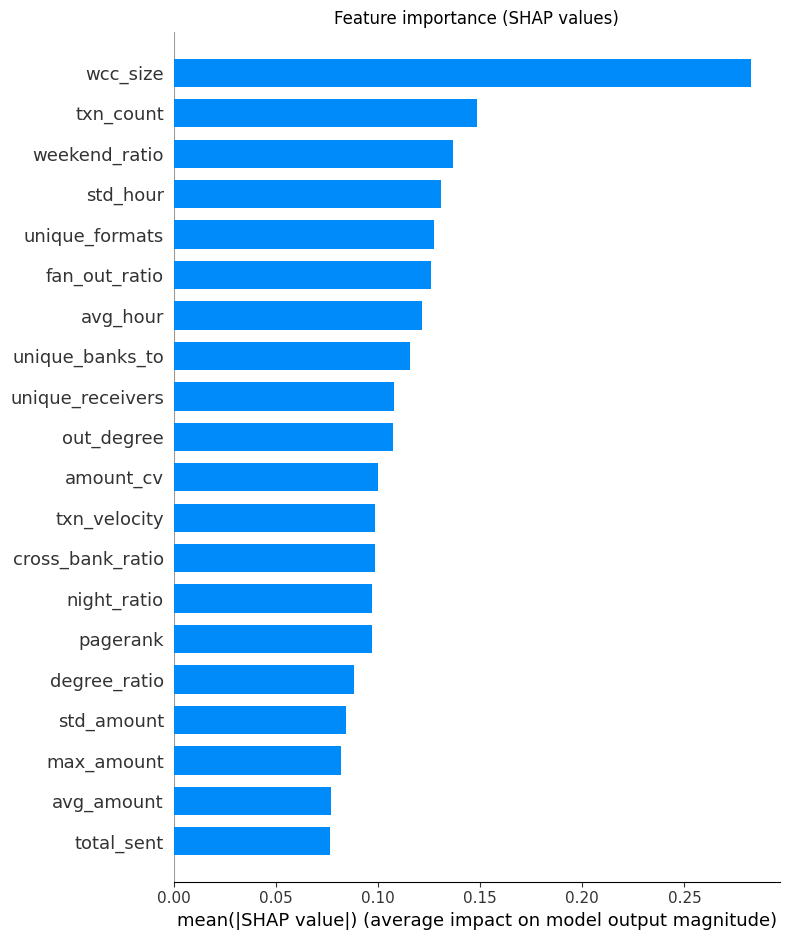

In [13]:
import shap

# TreeExplainer works directly on Isolation Forest
explainer = shap.TreeExplainer(iso)

# Use a sample for speed — 2000 rows is enough
sample_idx = np.random.choice(len(X_test_s), min(2000, len(X_test_s)), replace=False)
shap_values = explainer.shap_values(X_test_s[sample_idx])

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test_s[sample_idx],
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False,
    max_display=20,
)
plt.title('Feature importance (SHAP values)')
plt.tight_layout()
plt.savefig('/content/shap_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import pandas as pd
import numpy as np

# =========================
# CORE METRICS
# =========================

accuracy  = accuracy_score(y_test, final_preds)

precision = precision_score(
    y_test,
    final_preds,
    zero_division=0
)

recall = recall_score(
    y_test,
    final_preds,
    zero_division=0
)

f1 = f1_score(
    y_test,
    final_preds,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    suspicion_scores
)

pr_auc = average_precision_score(
    y_test,
    suspicion_scores
)

# =========================
# PRINT RESULTS
# =========================

print("=" * 70)
print("FINAL AML ISOLATION FOREST RESULTS")
print("=" * 70)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"F1 Score        : {f1:.4f}")
print(f"ROC-AUC Score   : {roc_auc:.4f}")
print(f"PR-AUC Score    : {pr_auc:.4f}")

print("\n")

# =========================
# CLASSIFICATION REPORT
# =========================

print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_preds,
        target_names=[
            "Normal",
            "Laundering"
        ]
    )
)

print("\n")

# =========================
# CONFUSION MATRIX
# =========================

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(
    y_test,
    final_preds
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Normal",
        "Actual Laundering"
    ],
    columns=[
        "Predicted Normal",
        "Predicted Laundering"
    ]
)

print(cm_df)

print("\n")

# =========================
# AML DETECTION SUMMARY
# =========================

total_accounts = len(y_test)

actual_fraud = np.sum(y_test)

detected_fraud = np.sum(
    (y_test == 1) &
    (final_preds == 1)
)

false_positives = np.sum(
    (y_test == 0) &
    (final_preds == 1)
)

print("=" * 70)
print("AML DETECTION SUMMARY")
print("=" * 70)

print(f"Total Accounts Checked        : {total_accounts}")

print(f"Actual Laundering Accounts    : {actual_fraud}")

print(f"Detected Laundering Accounts  : {detected_fraud}")

print(f"False Positive Alerts         : {false_positives}")

if actual_fraud > 0:
    detection_rate = (
        detected_fraud / actual_fraud
    ) * 100
else:
    detection_rate = 0

print(f"Fraud Detection Rate          : {detection_rate:.2f}%")

print("\n")

# =========================
# MODEL QUALITY LABEL
# =========================

print("=" * 70)
print("MODEL QUALITY")
print("=" * 70)

if roc_auc >= 0.90:
    print("EXCELLENT AML MODEL")

elif roc_auc >= 0.80:
    print("VERY GOOD AML MODEL")

elif roc_auc >= 0.70:
    print("GOOD AML MODEL")

elif roc_auc >= 0.60:
    print("DECENT AML MODEL")

else:
    print("MODEL NEEDS IMPROVEMENT")

print("\n")

# =========================
# SAVE RESULTS TO CSV
# =========================

results_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

results_df.to_csv(
    "/content/final_model_results.csv",
    index=False
)

print("Saved:")
print("/content/final_model_results.csv")

FINAL AML ISOLATION FOREST RESULTS
Accuracy        : 0.9811
Precision       : 0.0275
Recall          : 0.0825
F1 Score        : 0.0412
ROC-AUC Score   : 0.7914
PR-AUC Score    : 0.0252


CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99    232244
  Laundering       0.03      0.08      0.04      1152

    accuracy                           0.98    233396
   macro avg       0.51      0.53      0.52    233396
weighted avg       0.99      0.98      0.99    233396



CONFUSION MATRIX
                   Predicted Normal  Predicted Laundering
Actual Normal                228884                  3360
Actual Laundering              1057                    95


AML DETECTION SUMMARY
Total Accounts Checked        : 233396
Actual Laundering Accounts    : 1152
Detected Laundering Accounts  : 95
False Positive Alerts         : 3360
Fraud Detection Rate          : 8.25%


MODEL QUALITY
GOOD AML MODEL


Saved:
/content/final_model_

In [15]:
# Save everything the FastAPI backend will need
joblib.dump(iso, '/content/isolation_forest.pkl')
joblib.dump(scaler, '/content/scaler.pkl')
joblib.dump({
    'threshold'    : best_thresh,
    'feature_cols' : FEATURE_COLS,
    'roc_auc'      : roc_auc,
    'pr_auc'       : pr_auc,
    'fraud_rate'   : fraud_rate,
}, '/content/model_metadata.pkl')

# Quick reload verify
iso2 = joblib.load('/content/isolation_forest.pkl')
sc2  = joblib.load('/content/scaler.pkl')
meta = joblib.load('/content/model_metadata.pkl')
test_row = sc2.transform(X_test[:3])
print("Reload verify:", iso2.predict(test_row))
print("Saved metadata:", {k:v for k,v in meta.items() if k != 'feature_cols'})

# Download all files
from google.colab import files
for f in ['/content/isolation_forest.pkl', '/content/scaler.pkl',
          '/content/model_metadata.pkl', '/content/feature_matrix.csv',
          '/content/evaluation.png', '/content/shap_importance.png']:
    files.download(f)

Reload verify: [1 1 1]
Saved metadata: {'threshold': np.float64(0.5939713490357651), 'roc_auc': np.float64(0.7913555359311998), 'pr_auc': np.float64(0.025226096577234507), 'fraud_rate': np.float64(0.004933674955868995)}


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 300 out of 300 | elapsed:    0.0s finished


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>